# Experiment 8 — Capping: Theoretical vs Empirical Optimal Threshold $c^*$

**Setup:** Control $X \sim \text{LogNormal}$, Treatment $Y = X + \tau(X)$.  
Cap both at $c$: $X_c = \min(X,c)$, $Y_c = \min(Y,c)$.

$$\text{SNR}(c) = \frac{f(c)}{\sqrt{V(c)}}, \quad f(c)=E[Y_c]-E[X_c], \quad V(c)=\text{Var}(X_c)$$

**Theoretical FOC** (first-order condition for $c^*$):
$$f'(c^*)\cdot V(c^*) = f(c^*)\cdot \bar{F}(c^*)\cdot(c^* - \mu(c^*))$$
where $\mu(c)=E[X_c]=\int_0^c\bar{F}(u)\,du$ and $V(c)=2\int_0^c u\bar{F}(u)\,du - \mu(c)^2$.

| Effect | $f(c)$ | $f'(c)$ |
|---|---|---|
| Constant $\tau$ | $\int_{c-\tau}^{c}F(u)\,du$ | $\bar{F}(c-\tau)-\bar{F}(c)$ |
| Linear $\alpha$ | $(1+\alpha)\mu(c/(1+\alpha))-\mu(c)$ | $\bar{F}(c/(1+\alpha))-\bar{F}(c)$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, integrate, optimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Generate Skewed Dummy Data

Distribution: LogNormal(mu=0.5, sigma=0.9)
  X:  mean=2.474, std=2.748, median=1.653, 95th=7.282
  Y_const (τ=1.0):  mean=3.474
  Y_lin   (α=0.2): mean=2.969


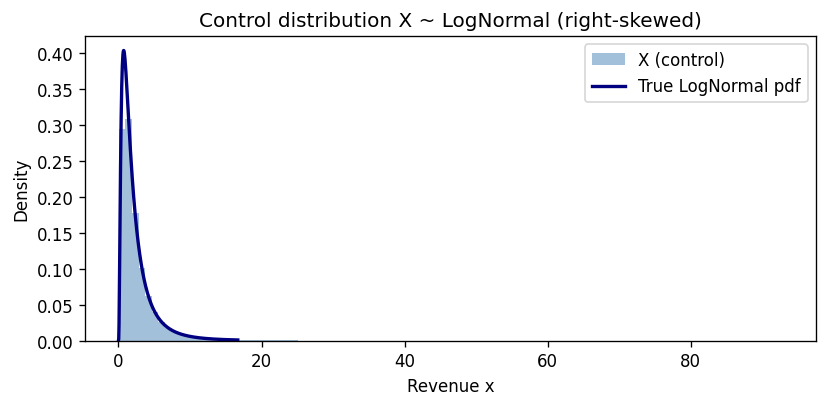

In [2]:
N = 100_000

# Log-normal: right-skewed, non-negative — mimics revenue
LOG_MU    = 0.5
LOG_SIGMA = 0.9
dist = stats.lognorm(s=LOG_SIGMA, scale=np.exp(LOG_MU))

X = dist.rvs(N)

# Treatment effects
TAU   = 1.0    # constant additive effect
ALPHA = 0.20   # linear multiplicative effect (20% lift)

Y_const = X + TAU
Y_lin   = (1 + ALPHA) * X

print(f"Distribution: LogNormal(mu={LOG_MU}, sigma={LOG_SIGMA})")
print(f"  X:  mean={X.mean():.3f}, std={X.std():.3f}, "
      f"median={np.median(X):.3f}, 95th={np.percentile(X,95):.3f}")
print(f"  Y_const (τ={TAU}):  mean={Y_const.mean():.3f}")
print(f"  Y_lin   (α={ALPHA}): mean={Y_lin.mean():.3f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
ax.hist(X, bins=100, density=True, alpha=0.5, color='steelblue', label='X (control)')
x_plot = np.linspace(0, np.percentile(X, 99.5), 400)
ax.plot(x_plot, dist.pdf(x_plot), 'navy', lw=2, label='True LogNormal pdf')
ax.set_xlabel('Revenue x'); ax.set_ylabel('Density')
ax.set_title('Control distribution X ~ LogNormal (right-skewed)')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Theoretical Quantities (Analytical, True Distribution)

In [3]:
# ── Shared: capped moments of X ──────────────────────────────────────────────

def mu_cap(c):
    """E[min(X,c)] = ∫₀ᶜ S(u) du   (survival-function formula)"""
    v, _ = integrate.quad(dist.sf, 0, c, limit=200)
    return v

def V_cap(c):
    """Var(min(X,c)) = 2∫₀ᶜ u·S(u) du − μ_cap(c)²"""
    m2, _ = integrate.quad(lambda u: 2*u*dist.sf(u), 0, c, limit=200)
    return m2 - mu_cap(c)**2

# ── Constant effect τ ─────────────────────────────────────────────────────────

def f_cap_const(c, tau=TAU):
    """f(c) = ∫_{c-τ}^{c} F(u) du"""
    lo = max(c - tau, 0.0)
    v, _ = integrate.quad(dist.cdf, lo, c, limit=200)
    return v

def f_prime_cap_const(c, tau=TAU):
    """f'(c) = F(c) − F(c−τ) = S(c−τ) − S(c)"""
    return dist.cdf(c) - dist.cdf(max(c - tau, 0.0))

def foc_cap_const(c, tau=TAU):
    """FOC residual = f'·V − f·S·(c−μ).  Zero at c*."""
    return (f_prime_cap_const(c, tau) * V_cap(c)
            - f_cap_const(c, tau) * dist.sf(c) * (c - mu_cap(c)))

# ── Linear effect Y=(1+α)X ────────────────────────────────────────────────────

def f_cap_lin(c, alpha=ALPHA):
    """f(c) = (1+α)·μ_cap(c/(1+α)) − μ_cap(c)"""
    return (1 + alpha) * mu_cap(c / (1 + alpha)) - mu_cap(c)

def f_prime_cap_lin(c, alpha=ALPHA):
    """f'(c) = S(c/(1+α)) − S(c)"""
    return dist.sf(c / (1 + alpha)) - dist.sf(c)

def foc_cap_lin(c, alpha=ALPHA):
    """FOC residual = f'·V − f·S·(c−μ).  Zero at c*."""
    return (f_prime_cap_lin(c, alpha) * V_cap(c)
            - f_cap_lin(c, alpha) * dist.sf(c) * (c - mu_cap(c)))

# ── Theoretical SNR curve ─────────────────────────────────────────────────────

def snr_cap_theory_const(c, tau=TAU):
    v = V_cap(c)
    return f_cap_const(c, tau) / np.sqrt(v) if v > 0 else 0.0

def snr_cap_theory_lin(c, alpha=ALPHA):
    v = V_cap(c)
    return f_cap_lin(c, alpha) / np.sqrt(v) if v > 0 else 0.0

print("Theoretical functions defined.")

Theoretical functions defined.


## 3. Find Theoretical $c^*$ via Root-Finding on FOC

In [4]:
c_scan = np.linspace(dist.ppf(0.30), dist.ppf(0.9995), 600)

# Evaluate FOC residuals over grid
foc_scan_const = np.array([foc_cap_const(c) for c in c_scan])
foc_scan_lin   = np.array([foc_cap_lin(c)   for c in c_scan])

def first_sign_change_bracket(vals, grid):
    """Return (a, b) where FOC changes sign from + to −."""
    for i in range(len(vals) - 1):
        if vals[i] > 0 and vals[i+1] < 0:
            return grid[i], grid[i+1]
    raise ValueError("No sign change found — check grid bounds.")

a_const, b_const = first_sign_change_bracket(foc_scan_const, c_scan)
a_lin,   b_lin   = first_sign_change_bracket(foc_scan_lin,   c_scan)

c_star_theory_const = optimize.brentq(foc_cap_const, a_const, b_const, xtol=1e-6)
c_star_theory_lin   = optimize.brentq(foc_cap_lin,   a_lin,   b_lin,   xtol=1e-6)

print(f"Theoretical c* — Constant effect (τ={TAU}):  {c_star_theory_const:.4f}")
print(f"Theoretical c* — Linear effect  (α={ALPHA}): {c_star_theory_lin:.4f}")

# Verify: FOC residual is ~0 at c*
print(f"\nFOC residual check:")
print(f"  Constant: foc(c*)={foc_cap_const(c_star_theory_const):.2e}")
print(f"  Linear:   foc(c*)={foc_cap_lin(c_star_theory_lin):.2e}")

Theoretical c* — Constant effect (τ=1.0):  2.0522
Theoretical c* — Linear effect  (α=0.2): 5.7279

FOC residual check:
  Constant: foc(c*)=-4.41e-14
  Linear:   foc(c*)=-2.52e-11


## 4. Empirical $c^*$ via Grid Search on Samples

In [5]:
c_grid = np.linspace(np.percentile(X, 35), np.percentile(X, 99.9), 300)

def snr_cap_empirical(c, Xarr, Yarr):
    """SNR = (mean(Y_c) - mean(X_c)) / std(X_c)  — all N observations."""
    Xc = np.minimum(Xarr, c)
    Yc = np.minimum(Yarr, c)
    v  = Xc.var(ddof=1)
    return (Yc.mean() - Xc.mean()) / np.sqrt(v) if v > 0 else 0.0

def tstat_cap_empirical(c, Xarr, Yarr):
    """Two-sample t-statistic on capped data."""
    Xc = np.minimum(Xarr, c)
    Yc = np.minimum(Yarr, c)
    t, _ = stats.ttest_ind(Yc, Xc, equal_var=True)
    return t

# Constant effect
snr_emp_const   = np.array([snr_cap_empirical(c, X, Y_const)   for c in c_grid])
tstat_emp_const = np.array([tstat_cap_empirical(c, X, Y_const) for c in c_grid])

c_star_snr_const   = c_grid[np.argmax(snr_emp_const)]
c_star_tstat_const = c_grid[np.argmax(tstat_emp_const)]

# Linear effect
snr_emp_lin   = np.array([snr_cap_empirical(c, X, Y_lin)   for c in c_grid])
tstat_emp_lin = np.array([tstat_cap_empirical(c, X, Y_lin) for c in c_grid])

c_star_snr_lin   = c_grid[np.argmax(snr_emp_lin)]
c_star_tstat_lin = c_grid[np.argmax(tstat_emp_lin)]

# Theoretical SNR curve
snr_theory_const = np.array([snr_cap_theory_const(c) for c in c_scan])
snr_theory_lin   = np.array([snr_cap_theory_lin(c)   for c in c_scan])

print(f"{'Method':<26} {'Constant τ='+str(TAU):>14} {'Linear α='+str(ALPHA):>14}")
print("-" * 56)
print(f"{'Theoretical FOC c*':<26} {c_star_theory_const:>14.4f} {c_star_theory_lin:>14.4f}")
print(f"{'Empirical max-SNR c*':<26} {c_star_snr_const:>14.4f} {c_star_snr_lin:>14.4f}")
print(f"{'Empirical max-t c*':<26} {c_star_tstat_const:>14.4f} {c_star_tstat_lin:>14.4f}")

Method                     Constant τ=1.0   Linear α=0.2
--------------------------------------------------------
Theoretical FOC c*                 2.0522         5.7279
Empirical max-SNR c*               2.0882         6.0328
Empirical max-t c*                 1.7525         4.0185


## 5. Visualization

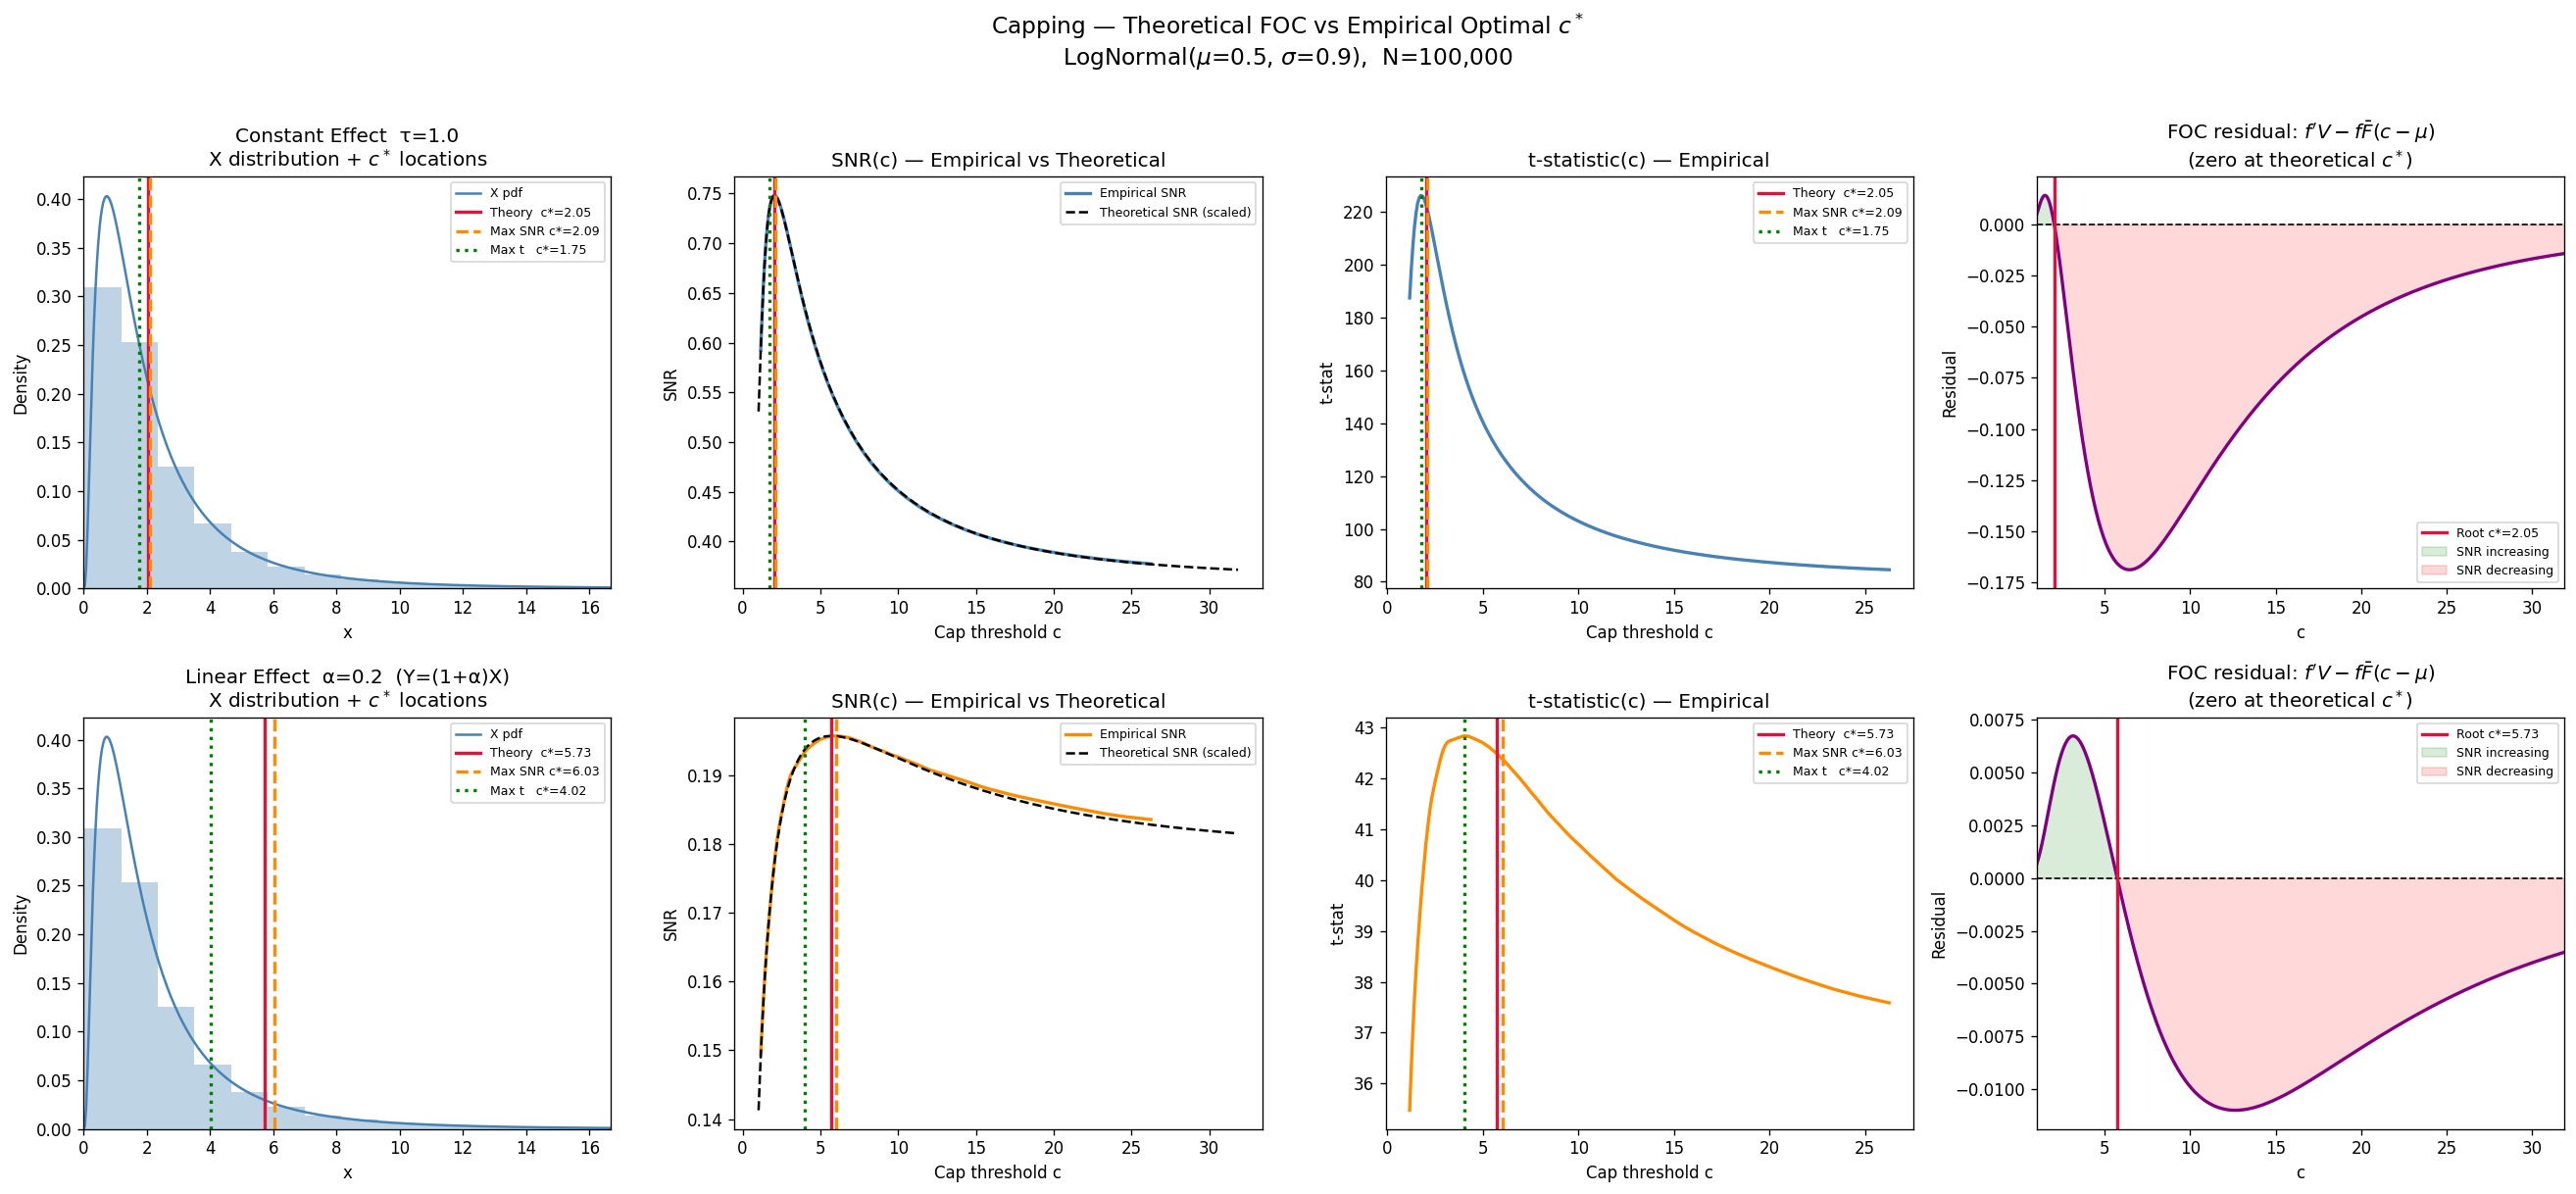

In [6]:
def plot_capping_case(axes_row, X, Y, c_grid, c_scan,
                      snr_emp, tstat_emp, snr_theory, foc_scan,
                      c_theory, c_snr, c_tstat,
                      title, row_color):
    """
    4-panel row: [histogram | SNR curves | t-stat curve | FOC residual]
    """
    ax_hist, ax_snr, ax_t, ax_foc = axes_row
    vlines = [
        (c_theory, 'crimson',    '-',  f'Theory  c*={c_theory:.2f}'),
        (c_snr,    'darkorange', '--', f'Max SNR c*={c_snr:.2f}'),
        (c_tstat,  'green',      ':',  f'Max t   c*={c_tstat:.2f}'),
    ]

    # ── Histogram ────────────────────────────────────────────────────
    x_plot = np.linspace(0, np.percentile(X, 99.5), 400)
    ax_hist.hist(X, bins=80, density=True, alpha=0.35, color='steelblue')
    ax_hist.plot(x_plot, dist.pdf(x_plot), 'steelblue', lw=1.5, label='X pdf')
    for cv, col, ls, lbl in vlines:
        ax_hist.axvline(cv, color=col, lw=2, linestyle=ls, label=lbl)
    ax_hist.set_xlim(0, np.percentile(X, 99.5))
    ax_hist.set_title(f'{title}\nX distribution + $c^*$ locations')
    ax_hist.set_xlabel('x'); ax_hist.set_ylabel('Density')
    ax_hist.legend(fontsize=7.5)

    # ── SNR curves: empirical + theoretical ──────────────────────────
    # Normalise theory curve to match empirical scale for shape comparison
    scale = snr_emp.max() / snr_theory.max() if snr_theory.max() > 0 else 1
    ax_snr.plot(c_grid, snr_emp,            color=row_color, lw=2,
                label='Empirical SNR')
    ax_snr.plot(c_scan, snr_theory * scale, color='black',   lw=1.5,
                linestyle='--', label='Theoretical SNR (scaled)')
    for cv, col, ls, lbl in vlines:
        ax_snr.axvline(cv, color=col, lw=2, linestyle=ls)
    ax_snr.set_title('SNR(c) — Empirical vs Theoretical')
    ax_snr.set_xlabel('Cap threshold c'); ax_snr.set_ylabel('SNR')
    ax_snr.legend(fontsize=7.5)

    # ── t-stat curve ─────────────────────────────────────────────────
    ax_t.plot(c_grid, tstat_emp, color=row_color, lw=2)
    for cv, col, ls, lbl in vlines:
        ax_t.axvline(cv, color=col, lw=2, linestyle=ls, label=lbl)
    ax_t.set_title('t-statistic(c) — Empirical')
    ax_t.set_xlabel('Cap threshold c'); ax_t.set_ylabel('t-stat')
    ax_t.legend(fontsize=7.5)

    # ── FOC residual ─────────────────────────────────────────────────
    ax_foc.plot(c_scan, foc_scan, color='purple', lw=2)
    ax_foc.axhline(0, color='k', lw=1, linestyle='--')
    ax_foc.axvline(c_theory, color='crimson', lw=2, linestyle='-',
                   label=f'Root c*={c_theory:.2f}')
    ax_foc.fill_between(c_scan, foc_scan, 0,
                         where=(foc_scan > 0), alpha=0.15, color='green',
                         label='SNR increasing')
    ax_foc.fill_between(c_scan, foc_scan, 0,
                         where=(foc_scan < 0), alpha=0.15, color='red',
                         label='SNR decreasing')
    ax_foc.set_title("FOC residual: $f'V - f\\bar{F}(c-\\mu)$\n(zero at theoretical $c^*$)")
    ax_foc.set_xlabel('c'); ax_foc.set_ylabel('Residual')
    ax_foc.set_xlim(c_scan[0], c_scan[-1])
    ax_foc.legend(fontsize=7.5)


fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle(
    'Capping — Theoretical FOC vs Empirical Optimal $c^*$\n'
    f'LogNormal($\\mu$={LOG_MU}, $\\sigma$={LOG_SIGMA}),  N={N:,}',
    fontsize=14, y=1.01)

plot_capping_case(
    axes[0], X, Y_const, c_grid, c_scan,
    snr_emp_const, tstat_emp_const, snr_theory_const, foc_scan_const,
    c_star_theory_const, c_star_snr_const, c_star_tstat_const,
    f'Constant Effect  τ={TAU}', 'steelblue')

plot_capping_case(
    axes[1], X, Y_lin, c_grid, c_scan,
    snr_emp_lin, tstat_emp_lin, snr_theory_lin, foc_scan_lin,
    c_star_theory_lin, c_star_snr_lin, c_star_tstat_lin,
    f'Linear Effect  α={ALPHA}  (Y=(1+α)X)', 'darkorange')

plt.tight_layout()
plt.savefig('capping_main.png', dpi=150, bbox_inches='tight')
plt.show()

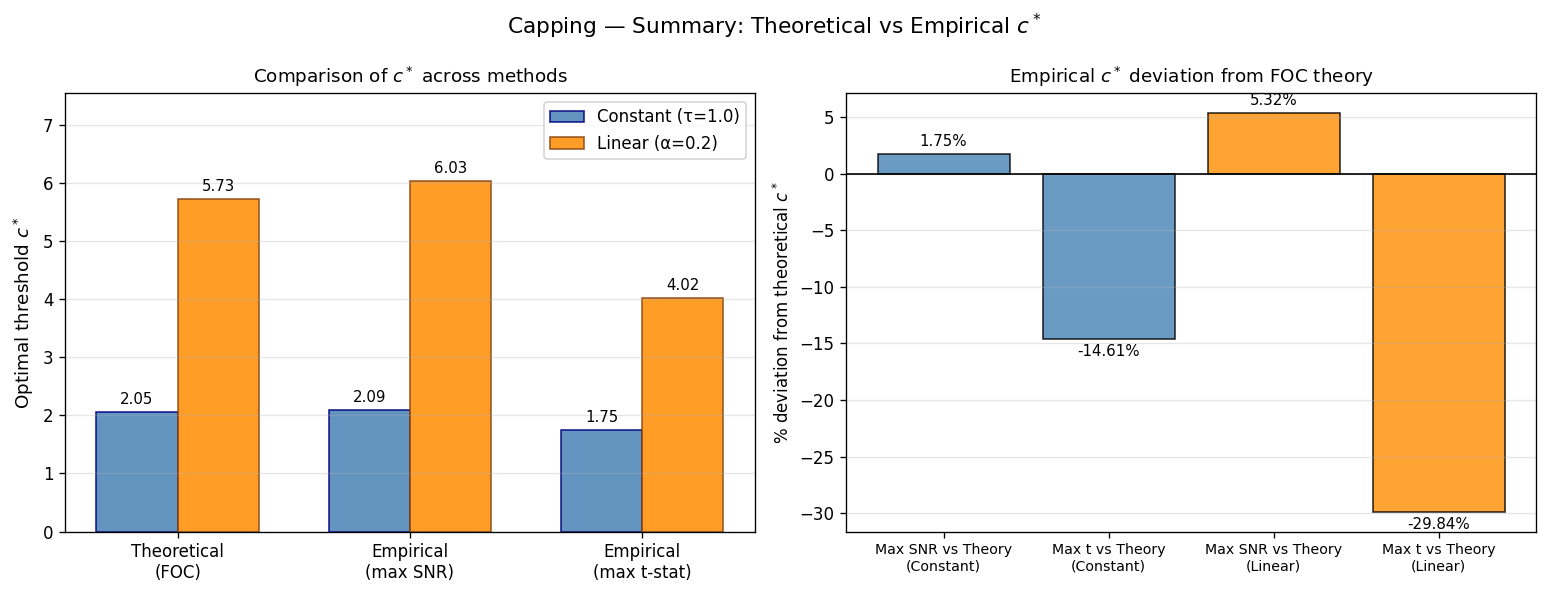


── Final Summary ──
Constant effect (τ=1.0):
  Theory c*=2.0522 | max-SNR c*=2.0882 (+1.75%) | max-t c*=1.7525 (-14.61%)
Linear effect (α=0.2):
  Theory c*=5.7279 | max-SNR c*=6.0328 (+5.32%) | max-t c*=4.0185 (-29.84%)


In [7]:
# ── Summary: bar chart + scatter comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Capping — Summary: Theoretical vs Empirical $c^*$', fontsize=13)

methods = ['Theoretical\n(FOC)', 'Empirical\n(max SNR)', 'Empirical\n(max t-stat)']
x_pos   = np.arange(len(methods))
w       = 0.35

vals_const = [c_star_theory_const, c_star_snr_const, c_star_tstat_const]
vals_lin   = [c_star_theory_lin,   c_star_snr_lin,   c_star_tstat_lin]

# Bar chart
ax = axes[0]
b1 = ax.bar(x_pos - w/2, vals_const, w, label=f'Constant (τ={TAU})',
            color='steelblue', alpha=0.85, edgecolor='navy')
b2 = ax.bar(x_pos + w/2, vals_lin,   w, label=f'Linear (α={ALPHA})',
            color='darkorange', alpha=0.85, edgecolor='saddlebrown')
ax.bar_label(b1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.2f', padding=3, fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(methods, fontsize=10)
ax.set_ylabel('Optimal threshold $c^*$', fontsize=11)
ax.set_title('Comparison of $c^*$ across methods', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ymax = max(max(vals_const), max(vals_lin)) * 1.25
ax.set_ylim(0, ymax)

# Error relative to theory (% deviation)
ax2 = axes[1]
dev_snr_const   = 100*(c_star_snr_const   - c_star_theory_const) / c_star_theory_const
dev_tstat_const = 100*(c_star_tstat_const - c_star_theory_const) / c_star_theory_const
dev_snr_lin     = 100*(c_star_snr_lin     - c_star_theory_lin)   / c_star_theory_lin
dev_tstat_lin   = 100*(c_star_tstat_lin   - c_star_theory_lin)   / c_star_theory_lin

cats  = ['Max SNR vs Theory\n(Constant)', 'Max t vs Theory\n(Constant)',
          'Max SNR vs Theory\n(Linear)',   'Max t vs Theory\n(Linear)']
devs  = [dev_snr_const, dev_tstat_const, dev_snr_lin, dev_tstat_lin]
cols  = ['steelblue', 'steelblue', 'darkorange', 'darkorange']
bars  = ax2.bar(cats, devs, color=cols, alpha=0.8, edgecolor='k')
ax2.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax2.axhline(0, color='k', lw=1)
ax2.set_ylabel('% deviation from theoretical $c^*$', fontsize=10)
ax2.set_title('Empirical $c^*$ deviation from FOC theory', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', labelsize=8.5)

plt.tight_layout()
plt.savefig('capping_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Final Summary ──")
print(f"Constant effect (τ={TAU}):")
print(f"  Theory c*={c_star_theory_const:.4f} | "
      f"max-SNR c*={c_star_snr_const:.4f} ({dev_snr_const:+.2f}%) | "
      f"max-t c*={c_star_tstat_const:.4f} ({dev_tstat_const:+.2f}%)")
print(f"Linear effect (α={ALPHA}):")
print(f"  Theory c*={c_star_theory_lin:.4f} | "
      f"max-SNR c*={c_star_snr_lin:.4f} ({dev_snr_lin:+.2f}%) | "
      f"max-t c*={c_star_tstat_lin:.4f} ({dev_tstat_lin:+.2f}%)")